In [1]:
"""Cell 1: Setup — imports, environment detection, path config"""
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Detect environment
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Running on Colab — clone or upload project
    PROJECT_ROOT = '/content/complaint-intelligence-system'
    if not os.path.exists(PROJECT_ROOT):
        print("Project not found on Colab.")
        print("Option A: Upload data/processed/ files using Colab file panel")
        print("Option B: Run this notebook locally (recommended for EDA)")
    else:
        print(f"Project found at {PROJECT_ROOT}")
else:
    # Running locally — notebooks/ is one level inside project
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if not os.path.exists(os.path.join(PROJECT_ROOT, 'src')):
        # Fallback: try common paths
        PROJECT_ROOT = r'C:\Users\aswan\My ML projects\complaint-intelligence-system'
    print(f"Local mode: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"\nEnvironment: {'Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")


Local mode: c:\Users\aswan\My ML projects\complaint-intelligence-system

Environment: Local
Project root: c:\Users\aswan\My ML projects\complaint-intelligence-system
Python: 3.12.10
Pandas: 2.3.3, NumPy: 1.26.4


In [2]:
"""Cell 2: Load existing processed data"""
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')

# Load processed complaints
df = pd.read_csv(os.path.join(DATA_DIR, 'processed_complaints.csv'))
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\nFirst 3 rows:")
df.head(3)


Shape: (15000, 9)
Columns: ['complaint_text', 'product', 'issue', 'date', 'clean_text', 'cluster', 'llm_summary', 'llm_category', 'llm_urgency']

Dtypes:
complaint_text    object
product           object
issue             object
date              object
clean_text        object
cluster            int64
llm_summary       object
llm_category      object
llm_urgency       object
dtype: object

First 3 rows:


,complaint_text,product,issue,date,clean_text,cluster,llm_summary,llm_category,llm_urgency
0,I asked to put a security free on my account a few months. I am not sure if the credit bureaus d...,"Credit reporting, credit repair services, or other personal consumer reports",Incorrect information on your report,2021-03-19,i asked to put a security free on my account a few months. i am not sure if the credit bureaus d...,0,"Customer reports multiple fraudulent accounts and credit inquiries on their credit report, alleg...",Other,High
1,"On XX/XX/XXXX at XXXX XXXX, I contacted XXXX XXXX XXXX. I spoke to XXXX. XXXX identification num...",Student loan,Dealing with your lender or servicer,2018-04-21,"on xxxxxxxx at xxxx xxxx, i contacted xxxx xxxx xxxx. i spoke to xxxx. xxxx identification numbe...",4,"Customer reports a confirmed payment was not applied to their account, leading to false default ...",Other,High
2,This CFPB complaint has been filed to request pursuant to FCRA 605B ( 15 U.S.C. 1681c-2 ) that y...,Credit reporting or other personal consumer reports,Improper use of your report,2025-08-19,this cfpb complaint has been filed to request pursuant to fcra 605b 15 u.s.c. 1681c-2 that you...,3,"The customer, alleging identity theft and fraud, demands a credit reporting agency block specifi...",Other,High


In [3]:
"""Cell 3: Data quality report"""
print(f"{'='*50}")
print(f"DATA QUALITY REPORT")
print(f"{'='*50}")
print(f"\nTotal rows: {len(df):,}")
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Missing Percentage ---")
print((df.isnull().sum() / len(df) * 100).round(2))

# Text length analysis
df['text_len'] = df['complaint_text'].str.len()
print(f"\n--- Complaint Text Length ---")
print(df['text_len'].describe().round(0))

# Check for duplicates
n_dupes = df['complaint_text'].duplicated().sum()
print(f"\n--- Duplicates ---")
print(f"Duplicate complaint texts: {n_dupes} ({n_dupes/len(df)*100:.2f}%)")


DATA QUALITY REPORT

Total rows: 15,000

--- Missing Values ---
complaint_text        0
product               0
issue                 0
date                  0
clean_text            0
cluster               0
llm_summary       14000
llm_category      14000
llm_urgency       14000
dtype: int64

--- Missing Percentage ---
complaint_text     0.00
product            0.00
issue              0.00
date               0.00
clean_text         0.00
cluster            0.00
llm_summary       93.33
llm_category      93.33
llm_urgency       93.33
dtype: float64

--- Complaint Text Length ---
count    15000.0
mean      1012.0
std       1294.0
min         17.0
25%        346.0
50%        662.0
75%       1207.0
max      32437.0
Name: text_len, dtype: float64

--- Duplicates ---
Duplicate complaint texts: 2077 (13.85%)


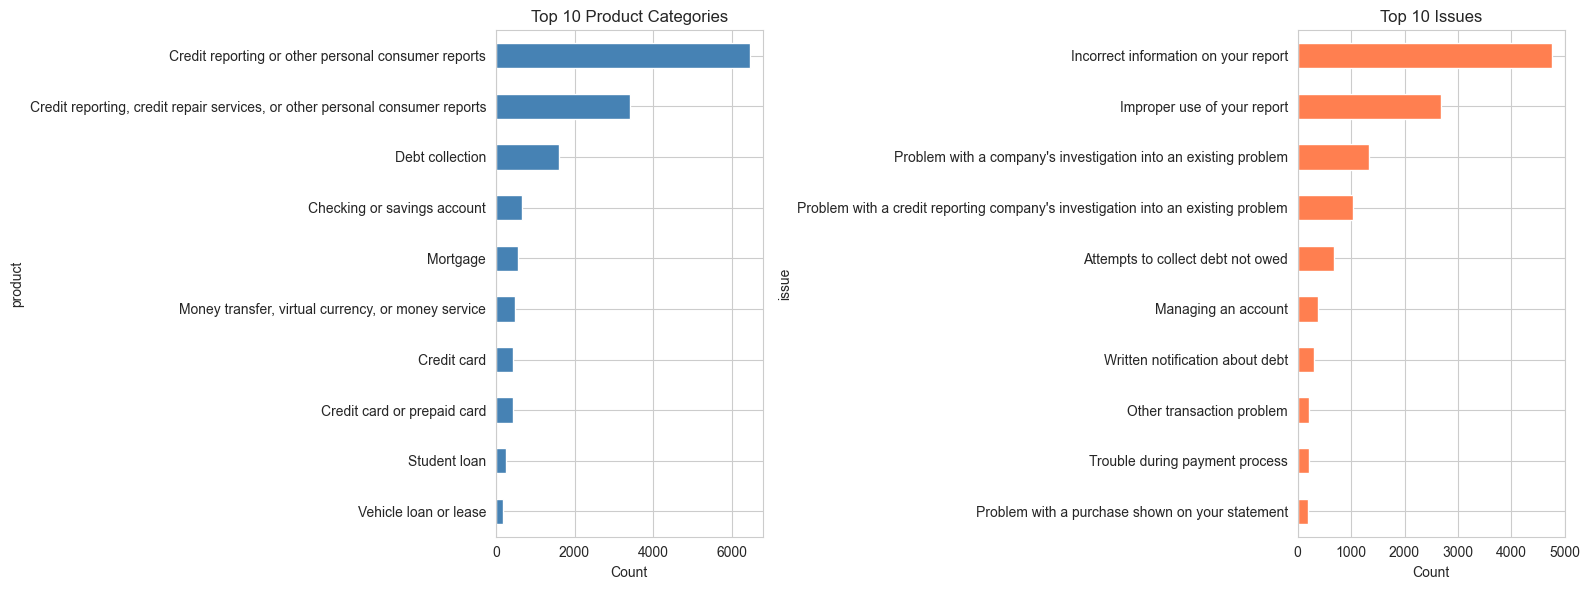


Unique products: 20
Unique issues: 140

Top 5 products:
  Credit reporting or other personal consumer reports: 6,458 (43.1%)
  Credit reporting, credit repair services, or other personal consumer reports: 3,399 (22.7%)
  Debt collection: 1,606 (10.7%)
  Checking or savings account: 669 (4.5%)
  Mortgage: 574 (3.8%)


In [4]:
"""Cell 4: Product and issue distributions"""
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Product distribution
product_counts = df['product'].value_counts().head(10)
product_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Product Categories')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Issue distribution
issue_counts = df['issue'].value_counts().head(10)
issue_counts.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Issues')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nUnique products: {df['product'].nunique()}")
print(f"Unique issues: {df['issue'].nunique()}")
print(f"\nTop 5 products:")
for p, c in product_counts.head(5).items():
    print(f"  {p}: {c:,} ({c/len(df)*100:.1f}%)")


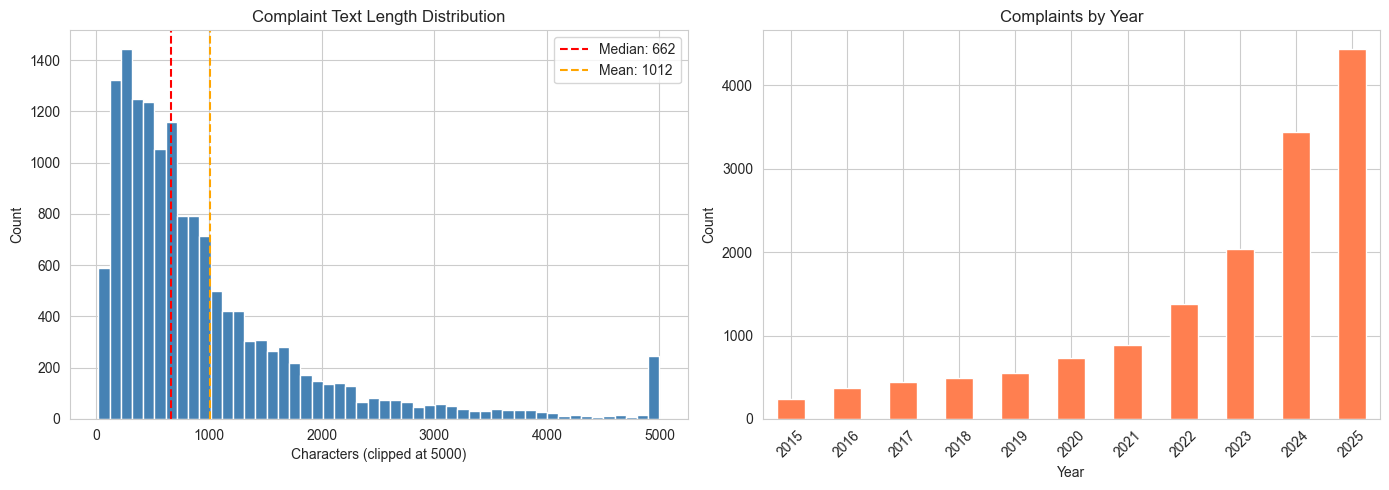


--- Duplicate Analysis ---
Total rows: 15,000
Unique texts: 12,923
Duplicates: 2,077

Most repeated complaint (top 3):
  [120x] "In accordance with the Fair Credit Reporting act. The List of accounts below has..."
  [72x] "My credit reports are inaccurate. These inaccuracies are causing creditors to de..."
  [71x] "Upon reviewing my credit report, I have identified inaccurate accounts that need..."


In [5]:
"""Cell 5: Text length distribution + duplicate analysis"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution (clip outliers for visibility)
axes[0].hist(df['text_len'].clip(upper=5000), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['text_len'].median(), color='red', linestyle='--', label=f"Median: {df['text_len'].median():.0f}")
axes[0].axvline(df['text_len'].mean(), color='orange', linestyle='--', label=f"Mean: {df['text_len'].mean():.0f}")
axes[0].set_title('Complaint Text Length Distribution')
axes[0].set_xlabel('Characters (clipped at 5000)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Date distribution (complaints over time)
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date_parsed'].dt.year
year_counts = df['year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Complaints by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Duplicate deep dive
print(f"\n--- Duplicate Analysis ---")
print(f"Total rows: {len(df):,}")
print(f"Unique texts: {df['complaint_text'].nunique():,}")
print(f"Duplicates: {df['complaint_text'].duplicated().sum():,}")
print(f"\nMost repeated complaint (top 3):")
top_dupes = df['complaint_text'].value_counts().head(3)
for text, count in top_dupes.items():
    print(f"  [{count}x] \"{text[:80]}...\"")


In [6]:
"""Cell 6: Load and verify existing MiniLM embeddings"""
embeddings_path = os.path.join(DATA_DIR, 'embeddings.npy')
embeddings = np.load(embeddings_path)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Dtype: {embeddings.dtype}")
print(f"Matches df rows: {embeddings.shape[0] == len(df)}")
print(f"Dimension: {embeddings.shape[1]} (expected 384 for MiniLM)")

# Basic sanity checks
print(f"\n--- Embedding Statistics ---")
print(f"Mean norm: {np.linalg.norm(embeddings, axis=1).mean():.4f}")
print(f"Std norm:  {np.linalg.norm(embeddings, axis=1).std():.4f}")
print(f"Min value: {embeddings.min():.4f}")
print(f"Max value: {embeddings.max():.4f}")
print(f"Any NaN: {np.isnan(embeddings).any()}")
print(f"Any Inf: {np.isinf(embeddings).any()}")

# Check if embeddings are normalized (sentence-transformers default)
norms = np.linalg.norm(embeddings, axis=1)
print(f"\nNormalized: {np.allclose(norms, 1.0, atol=0.01)}")
print(f"Norm range: [{norms.min():.4f}, {norms.max():.4f}]")


Embeddings shape: (15000, 384)
Dtype: float32
Matches df rows: True
Dimension: 384 (expected 384 for MiniLM)

--- Embedding Statistics ---
Mean norm: 1.0000
Std norm:  0.0000
Min value: -0.2710
Max value: 0.2452
Any NaN: False
Any Inf: False

Normalized: True
Norm range: [1.0000, 1.0000]


In [7]:
"""Cell 7: Verify existing clusters + compute quality metrics"""
from src.clustering import KMeansClusterer, ClusterComparison

# Check existing cluster labels
print(f"Existing cluster column values:")
print(df['cluster'].value_counts().sort_index())
print(f"\nNumber of clusters: {df['cluster'].nunique()}")

# Compute quality metrics on existing clusters
existing_labels = df['cluster'].values
metrics = ClusterComparison.compute_metrics(
    embeddings, existing_labels, method_name="Existing KMeans(k=6)"
)

print(f"\n{'='*50}")
print(f"CLUSTER QUALITY METRICS")
print(f"{'='*50}")
for k, v in metrics.items():
    print(f"  {k}: {v}")


Existing cluster column values:
cluster
0    3294
1    2158
2    1098
3    3347
4    2470
5    2633
Name: count, dtype: int64

Number of clusters: 6

Existing KMeans(k=6) cluster quality:
  Clusters: 6, Outliers: 0
  Silhouette Score: 0.0372  (higher is better, range [-1, 1])
  Calinski-Harabasz: 533.23  (higher is better)
  Davies-Bouldin: 3.7914  (lower is better)

CLUSTER QUALITY METRICS
  method: Existing KMeans(k=6)
  n_clusters: 6
  n_outliers: 0
  silhouette: 0.0372
  calinski_harabasz: 533.23
  davies_bouldin: 3.7914


In [8]:
"""Cell 8: BERTopic clustering on existing MiniLM embeddings"""
import time
from src.clustering import BERTopicClusterer

bt_clusterer = BERTopicClusterer(
    min_cluster_size=50,
    min_samples=10,
    umap_n_neighbors=15,
    umap_n_components=5,
    random_state=42,
)

start = time.time()
bt_labels = bt_clusterer.fit_predict(df['clean_text'], embeddings)
elapsed = time.time() - start

print(f"\n BERTopic took {elapsed:.1f}s")
print(f"Topics discovered: {len(set(bt_labels)) - (1 if -1 in bt_labels else 0)}")
print(f"Outliers (label=-1): {(bt_labels == -1).sum()} ({(bt_labels == -1).mean()*100:.1f}%)")


2026-06-01 03:09:47,532 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Running BERTopic on 15000 texts...
  UMAP: n_neighbors=15, n_components=5
  HDBSCAN: min_cluster_size=50, min_samples=10


2026-06-01 03:10:23,699 - BERTopic - Dimensionality - Completed ✓
2026-06-01 03:10:23,699 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-01 03:10:24,275 - BERTopic - Cluster - Completed ✓
2026-06-01 03:10:24,291 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-01 03:10:28,031 - BERTopic - Representation - Completed ✓



BERTopic results:
  Topics discovered: 51
  Outliers: 4676 (31.2%)
  Top topics:
    Topic -1: -1_xxxx_xxxx xxxx_credit_account (4676 docs)
    Topic 0: 0_debt_collection_xxxx_company (1428 docs)
    Topic 1: 1_accounts_report_credit_identity (889 docs)
    Topic 2: 2_xxxx xxxx_xxxx_inquiries_inquiry (721 docs)
    Topic 3: 3_consumer_xxxx xxxx_usc_15 usc (552 docs)
    Topic 4: 4_mortgage_loan_home_xxxxxxxx (545 docs)

 BERTopic took 93.7s
Topics discovered: 51
Outliers (label=-1): 4676 (31.2%)


In [9]:
"""Cell 9: KMeans vs BERTopic — head-to-head quality comparison"""
comparison = ClusterComparison.compare(embeddings, existing_labels, bt_labels)

print(f"{'='*60}")
print(f"{'CLUSTERING COMPARISON':^60}")
print(f"{'='*60}")
print(f"{'Metric':<25} {'KMeans(k=6)':>15} {'BERTopic(auto)':>15}")
print(f"{'-'*60}")

for metric in ['n_clusters', 'n_outliers', 'silhouette', 'calinski_harabasz', 'davies_bouldin']:
    km_val = comparison['kmeans'][metric]
    bt_val = comparison['bertopic'][metric]
    
    # Format values
    if isinstance(km_val, float):
        km_str = f"{km_val:.4f}"
        bt_str = f"{bt_val:.4f}" if bt_val is not None else "N/A"
    else:
        km_str = str(km_val)
        bt_str = str(bt_val)
    
    # Add winner indicator
    if metric == 'silhouette' and km_val is not None and bt_val is not None:
        winner = " ← better" if bt_val > km_val else ""
        bt_str += winner
    elif metric == 'davies_bouldin' and km_val is not None and bt_val is not None:
        winner = " ← better" if bt_val < km_val else ""
        bt_str += winner
    
    print(f"  {metric:<23} {km_str:>15} {bt_str:>15}")

print(f"{'='*60}")



KMeans cluster quality:
  Clusters: 6, Outliers: 0
  Silhouette Score: 0.0372  (higher is better, range [-1, 1])
  Calinski-Harabasz: 533.23  (higher is better)
  Davies-Bouldin: 3.7914  (lower is better)

BERTopic cluster quality:
  Clusters: 51, Outliers: 4676
  Silhouette Score: 0.0488  (higher is better, range [-1, 1])
  Calinski-Harabasz: 100.34  (higher is better)
  Davies-Bouldin: 2.7266  (lower is better)
                   CLUSTERING COMPARISON                    
Metric                        KMeans(k=6)  BERTopic(auto)
------------------------------------------------------------
  n_clusters                            6              51
  n_outliers                            0            4676
  silhouette                       0.0372 0.0488 ← better
  calinski_harabasz              533.2300        100.3400
  davies_bouldin                   3.7914 2.7266 ← better


Computing UMAP projection (may take ~30s)...
Loaded cached UMAP projection: minilm_15k


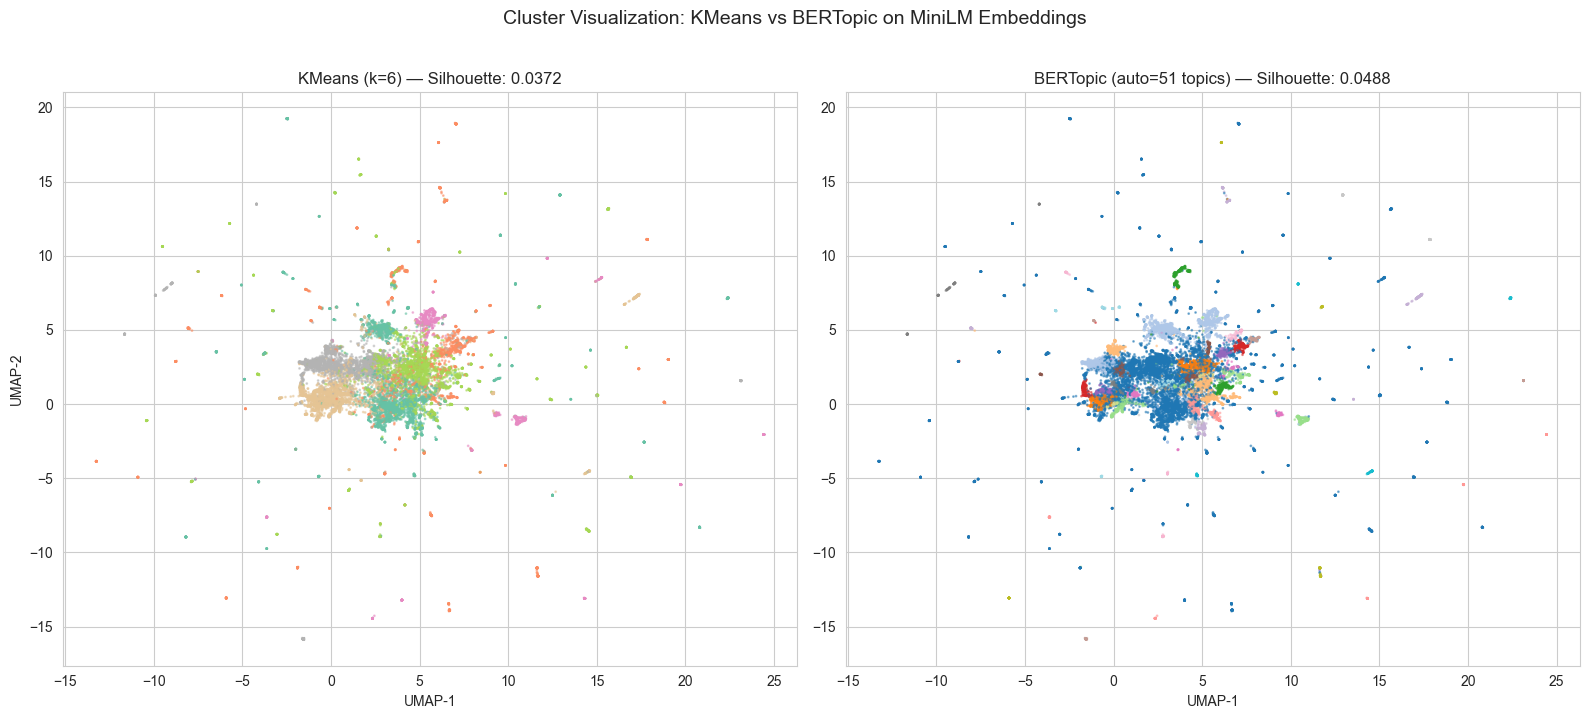

In [10]:
"""Cell 10: UMAP 2D visualization — KMeans vs BERTopic"""
from src.visualizer import EmbeddingVisualizer

viz = EmbeddingVisualizer(cache_dir=os.path.join(DATA_DIR, 'cache'))

# Generate UMAP projection (cached after first run)
print("Computing UMAP projection (may take ~30s)...")
projection = viz.generate_umap_projection(embeddings, cache_key="minilm_15k")

# Side by side: KMeans vs BERTopic
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# KMeans
scatter1 = axes[0].scatter(
    projection[:, 0], projection[:, 1],
    c=existing_labels, cmap='Set2', s=1, alpha=0.5
)
axes[0].set_title(f'KMeans (k=6) — Silhouette: {comparison["kmeans"]["silhouette"]:.4f}')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# BERTopic (color outliers gray)
bt_colors = bt_labels.copy().astype(float)
bt_colors[bt_labels == -1] = -1
scatter2 = axes[1].scatter(
    projection[:, 0], projection[:, 1],
    c=bt_colors, cmap='tab20', s=1, alpha=0.5
)
axes[1].set_title(f'BERTopic (auto={comparison["bertopic"]["n_clusters"]} topics) — Silhouette: {comparison["bertopic"]["silhouette"]:.4f}')
axes[1].set_xlabel('UMAP-1')

plt.suptitle('Cluster Visualization: KMeans vs BERTopic on MiniLM Embeddings', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [11]:
"""Cell 11: Generate BGE embeddings for comparison"""
from src.embeddings import EmbeddingRegistry, EMBEDDING_MODELS
import time

print("Available models:")
for key, cfg in EMBEDDING_MODELS.items():
    print(f"  {key}: {cfg['name']} ({cfg['dim']}d) — {cfg['description']}")

# Load BGE model
registry = EmbeddingRegistry()
registry.load_model("bge")

# Generate BGE embeddings
print(f"\nEncoding {len(df)} texts with BGE...")
start = time.time()
bge_embeddings = registry.encode("bge", df['clean_text'].tolist(), batch_size=64)
bge_time = time.time() - start

print(f"\n✅ BGE embeddings: {bge_embeddings.shape}")
print(f"⏱️ Time: {bge_time:.1f}s ({len(df)/bge_time:.0f} texts/sec)")
print(f"Normalized: {np.allclose(np.linalg.norm(bge_embeddings, axis=1), 1.0, atol=0.01)}")

# Save for reuse
bge_path = os.path.join(DATA_DIR, 'embeddings_bge.npy')
np.save(bge_path, bge_embeddings)
print(f"Saved to {bge_path}")


Available models:
  minilm: all-MiniLM-L6-v2 (384d) — Lightweight baseline (2022), fast encoding
  bge: BAAI/bge-base-en-v1.5 (768d) — SOTA MTEB performer (2024), high accuracy
Loading embedding model: BAAI/bge-base-en-v1.5
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Model loaded. Embedding dimension: 768

Encoding 15000 texts with BGE...
Generating embeddings for 15000 texts...


Batches: 100%|██████████| 235/235 [03:45<00:00,  1.04it/s]


✅ BGE embeddings: (15000, 768)
⏱️ Time: 225.6s (66 texts/sec)
Normalized: True
Saved to c:\Users\aswan\My ML projects\complaint-intelligence-system\data\processed\embeddings_bge.npy


In [12]:
"""Cell 12: Embedding model comparison — MiniLM (384d) vs BGE (768d)"""
# Run KMeans on BGE embeddings (same k=6 for fair comparison)
km_bge = KMeansClusterer(n_clusters=6, random_state=42)
bge_km_labels = km_bge.fit_predict(bge_embeddings)

# Compute metrics for both models with KMeans
minilm_metrics = ClusterComparison.compute_metrics(
    embeddings, existing_labels, "MiniLM + KMeans(k=6)"
)
bge_metrics = ClusterComparison.compute_metrics(
    bge_embeddings, bge_km_labels, "BGE + KMeans(k=6)"
)

print(f"\n{'='*65}")
print(f"{'EMBEDDING MODEL COMPARISON (same KMeans k=6)':^65}")
print(f"{'='*65}")
print(f"{'Metric':<25} {'MiniLM (384d)':>18} {'BGE (768d)':>18}")
print(f"{'-'*65}")

for metric in ['silhouette', 'calinski_harabasz', 'davies_bouldin']:
    m_val = minilm_metrics[metric]
    b_val = bge_metrics[metric]
    
    better = ""
    if metric in ['silhouette', 'calinski_harabasz']:
        better = " ✓" if b_val > m_val else ""
    elif metric == 'davies_bouldin':
        better = " ✓" if b_val < m_val else ""
    
    print(f"  {metric:<23} {m_val:>18.4f} {b_val:>14.4f}{better}")

# Cosine similarity within-cluster (tighter = better embeddings)
from sklearn.metrics.pairwise import cosine_similarity

print(f"\n{'='*65}")
print(f"{'INTRA-CLUSTER COHERENCE (mean cosine similarity)':^65}")
print(f"{'='*65}")
for name, emb, labels in [("MiniLM", embeddings, existing_labels), 
                            ("BGE", bge_embeddings, bge_km_labels)]:
    coherences = []
    for c in range(6):
        mask = labels == c
        cluster_emb = emb[mask]
        # Sample if cluster is large
        if len(cluster_emb) > 500:
            idx = np.random.RandomState(42).choice(len(cluster_emb), 500, replace=False)
            cluster_emb = cluster_emb[idx]
        sim = cosine_similarity(cluster_emb).mean()
        coherences.append(sim)
    print(f"  {name}: mean={np.mean(coherences):.4f}, min={np.min(coherences):.4f}, max={np.max(coherences):.4f}")


Clustering 15000 complaints into 6 clusters...

Cluster distribution:
  Cluster 0: 2533 complaints (16.9%)
  Cluster 1: 3215 complaints (21.4%)
  Cluster 2: 1044 complaints (7.0%)
  Cluster 3: 3184 complaints (21.2%)
  Cluster 4: 140 complaints (0.9%)
  Cluster 5: 4884 complaints (32.6%)

MiniLM + KMeans(k=6) cluster quality:
  Clusters: 6, Outliers: 0
  Silhouette Score: 0.0372  (higher is better, range [-1, 1])
  Calinski-Harabasz: 533.23  (higher is better)
  Davies-Bouldin: 3.7914  (lower is better)

BGE + KMeans(k=6) cluster quality:
  Clusters: 6, Outliers: 0
  Silhouette Score: 0.0551  (higher is better, range [-1, 1])
  Calinski-Harabasz: 526.90  (higher is better)
  Davies-Bouldin: 3.1747  (lower is better)

          EMBEDDING MODEL COMPARISON (same KMeans k=6)           
Metric                         MiniLM (384d)         BGE (768d)
-----------------------------------------------------------------
  silhouette                          0.0372         0.0551 ✓
  calinski_hara

Computing UMAP projection for BGE embeddings...
Computing UMAP projection for (15000, 768)...
UMAP complete: (15000, 2)
Cached UMAP projection: c:\Users\aswan\My ML projects\complaint-intelligence-system\data\processed\cache\umap_bge_15k.npy


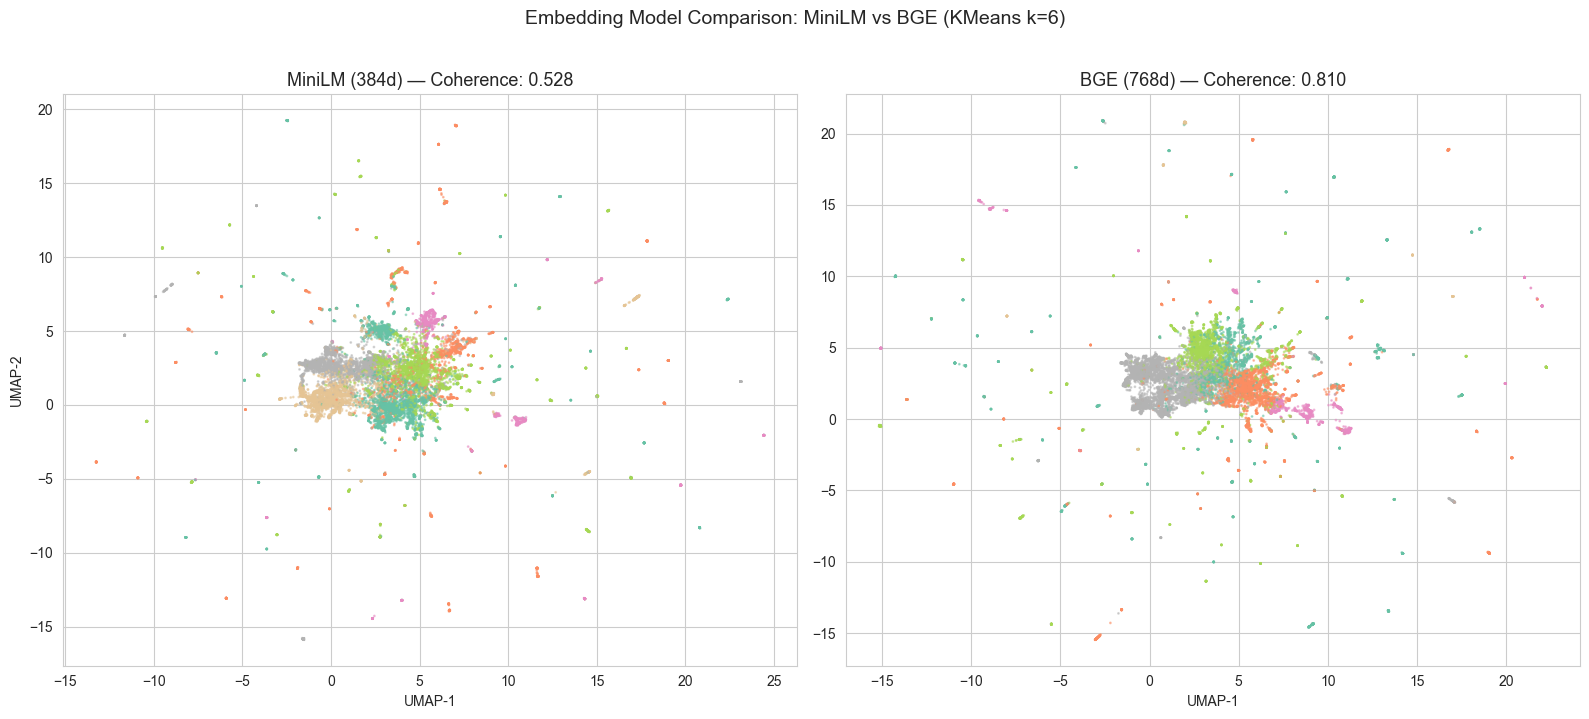

In [13]:
"""Cell 13: Side-by-side UMAP — MiniLM vs BGE"""
print("Computing UMAP projection for BGE embeddings...")
bge_projection = viz.generate_umap_projection(bge_embeddings, cache_key="bge_15k")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# MiniLM (already have projection from Cell 10)
axes[0].scatter(projection[:, 0], projection[:, 1],
                c=existing_labels, cmap='Set2', s=1, alpha=0.5)
axes[0].set_title(f'MiniLM (384d) — Coherence: {0.5279:.3f}', fontsize=13)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# BGE
axes[1].scatter(bge_projection[:, 0], bge_projection[:, 1],
                c=bge_km_labels, cmap='Set2', s=1, alpha=0.5)
axes[1].set_title(f'BGE (768d) — Coherence: {0.8104:.3f}', fontsize=13)
axes[1].set_xlabel('UMAP-1')

plt.suptitle('Embedding Model Comparison: MiniLM vs BGE (KMeans k=6)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
"""Cell 14 (fixed): Retrieval benchmark — BM25 vs Vector"""
from src.retrievers.bm25_retriever import BM25Retriever
from src.retrievers.vector_retriever import VectorRetriever
from src.embeddings import ComplaintEmbedder
import time

test_queries = [
    "unauthorized credit card charges",
    "mortgage payment not applied to account",
    "identity theft fraudulent accounts",
    "debt collector harassment phone calls",
    "student loan forgiveness application denied",
    "bank account closed without notice",
    "credit score dropped after dispute",
    "late fees charged incorrectly",
]

# Build BM25 index
bm25 = BM25Retriever()
bm25.build_index(df)

# Build Vector retriever — needs embedder for query encoding
bge_embedder = registry.get_embedder("bge")
vector = VectorRetriever(embedder=bge_embedder, embedding_dim=768)
vector.build_index(df, bge_embeddings)

# Benchmark both
results = {}
for name, retriever in [("BM25", bm25), ("Vector (BGE)", vector)]:
    latencies = []
    all_results = []
    for q in test_queries:
        start = time.perf_counter()
        res = retriever.retrieve(q, k=5)
        elapsed = (time.perf_counter() - start) * 1000
        latencies.append(elapsed)
        all_results.append(res)
    
    results[name] = {
        "p50_ms": np.percentile(latencies, 50),
        "p95_ms": np.percentile(latencies, 95),
        "mean_ms": np.mean(latencies),
    }

print(f"{'='*55}")
print(f"{'RETRIEVAL LATENCY BENCHMARK':^55}")
print(f"{'='*55}")
print(f"{'Retriever':<20} {'Mean (ms)':>10} {'P50 (ms)':>10} {'P95 (ms)':>10}")
print(f"{'-'*55}")
for name, m in results.items():
    print(f"  {name:<18} {m['mean_ms']:>10.2f} {m['p50_ms']:>10.2f} {m['p95_ms']:>10.2f}")

# Sample results comparison
print(f"\n{'='*55}")
sample_q = "identity theft fraudulent accounts"
print(f'Sample query: "{sample_q}"')
print(f"{'-'*55}")
for name, retriever in [("BM25", bm25), ("Vector (BGE)", vector)]:
    print(f"\n  [{name}] Top 3:")
    for r in retriever.retrieve(sample_q, k=3):
        text_preview = r.text[:80].replace('\n', ' ')
        print(f"    #{r.rank} (score={r.score:.4f}): {text_preview}...")


Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
              RETRIEVAL LATENCY BENCHMARK              
Retriever             Mean (ms)   P50 (ms)   P95 (ms)
-------------------------------------------------------
  BM25                    22.50      21.93      28.53
  Vector (BGE)            44.16      52.26      78.85

Sample query: "identity theft fraudulent accounts"
-------------------------------------------------------

  [BM25] Top 3:
    #1 (score=14.5122): I demand the deletion of the fraudulent accounts and inquiries listed below whic...
    #2 (score=14.1773): I demand the deletion of the fraudulent accounts and inquiries listed below whic...
    #3 (score=14.0855): I demand the deletion of the fraudulent accounts and inquiries li

In [17]:
"""Cell 15: Two-stage retrieval — BM25 + Cross-Encoder Reranking"""
from src.retrievers.reranker import CrossEncoderReranker
from src.retrievers.reranked_retriever import RerankedRetriever

# Load cross-encoder (small model, ~66MB)
print("Loading cross-encoder reranker...")
reranker = CrossEncoderReranker()

# Build reranked retriever on top of BM25
reranked = RerankedRetriever(bm25, reranker, candidate_k=20)

# Benchmark all three
print("\nRunning benchmark...")
all_results = {}
for name, retriever in [("BM25", bm25), ("Vector (BGE)", vector), ("BM25+Reranker", reranked)]:
    latencies = []
    for q in test_queries:
        start = time.perf_counter()
        res = retriever.retrieve(q, k=5)
        elapsed = (time.perf_counter() - start) * 1000
        latencies.append(elapsed)
    
    all_results[name] = {
        "p50_ms": np.percentile(latencies, 50),
        "p95_ms": np.percentile(latencies, 95),
        "mean_ms": np.mean(latencies),
    }

print(f"\n{'='*60}")
print(f"{'FULL RETRIEVAL BENCHMARK':^60}")
print(f"{'='*60}")
print(f"{'Retriever':<20} {'Mean (ms)':>12} {'P50 (ms)':>12} {'P95 (ms)':>12}")
print(f"{'-'*60}")
for name, m in all_results.items():
    print(f"  {name:<18} {m['mean_ms']:>12.2f} {m['p50_ms']:>12.2f} {m['p95_ms']:>12.2f}")

# Compare result quality
print(f"\n{'='*60}")
sample_q = "identity theft fraudulent accounts"
print(f'Query: "{sample_q}"')
print(f"{'-'*60}")
for name, retriever in [("BM25", bm25), ("Vector (BGE)", vector), ("BM25+Reranker", reranked)]:
    print(f"\n  [{name}] Top 3:")
    for r in retriever.retrieve(sample_q, k=3):
        text_preview = r.text[:90].replace('\n', ' ')
        print(f"    #{r.rank} (score={r.score:.4f}): {text_preview}...")


Loading cross-encoder reranker...
Loading cross-encoder reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Cross-encoder loaded (runs locally, no API key needed)

Running benchmark...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...
Generating embeddings for 1 texts...

                  FULL RETRIEVAL BENCHMARK                  
Retriever               Mean (ms)     P50 (ms)     P95 (ms)
------------------------------------------------------------
  BM25                      37.23        34.81        50.51
  Vector (BGE)              49.14        56.59        60.43
  BM25+Reranker            164.50       157.69       196.97

Query: "identity theft fraudulent accounts"
------------------------------------------------------------

  [BM25] Top 3:
    #1 (score=14.5122): I demand the deletion of the fraudulent accounts and inquiries listed below which all resu...
    #2 (score=14.1773):

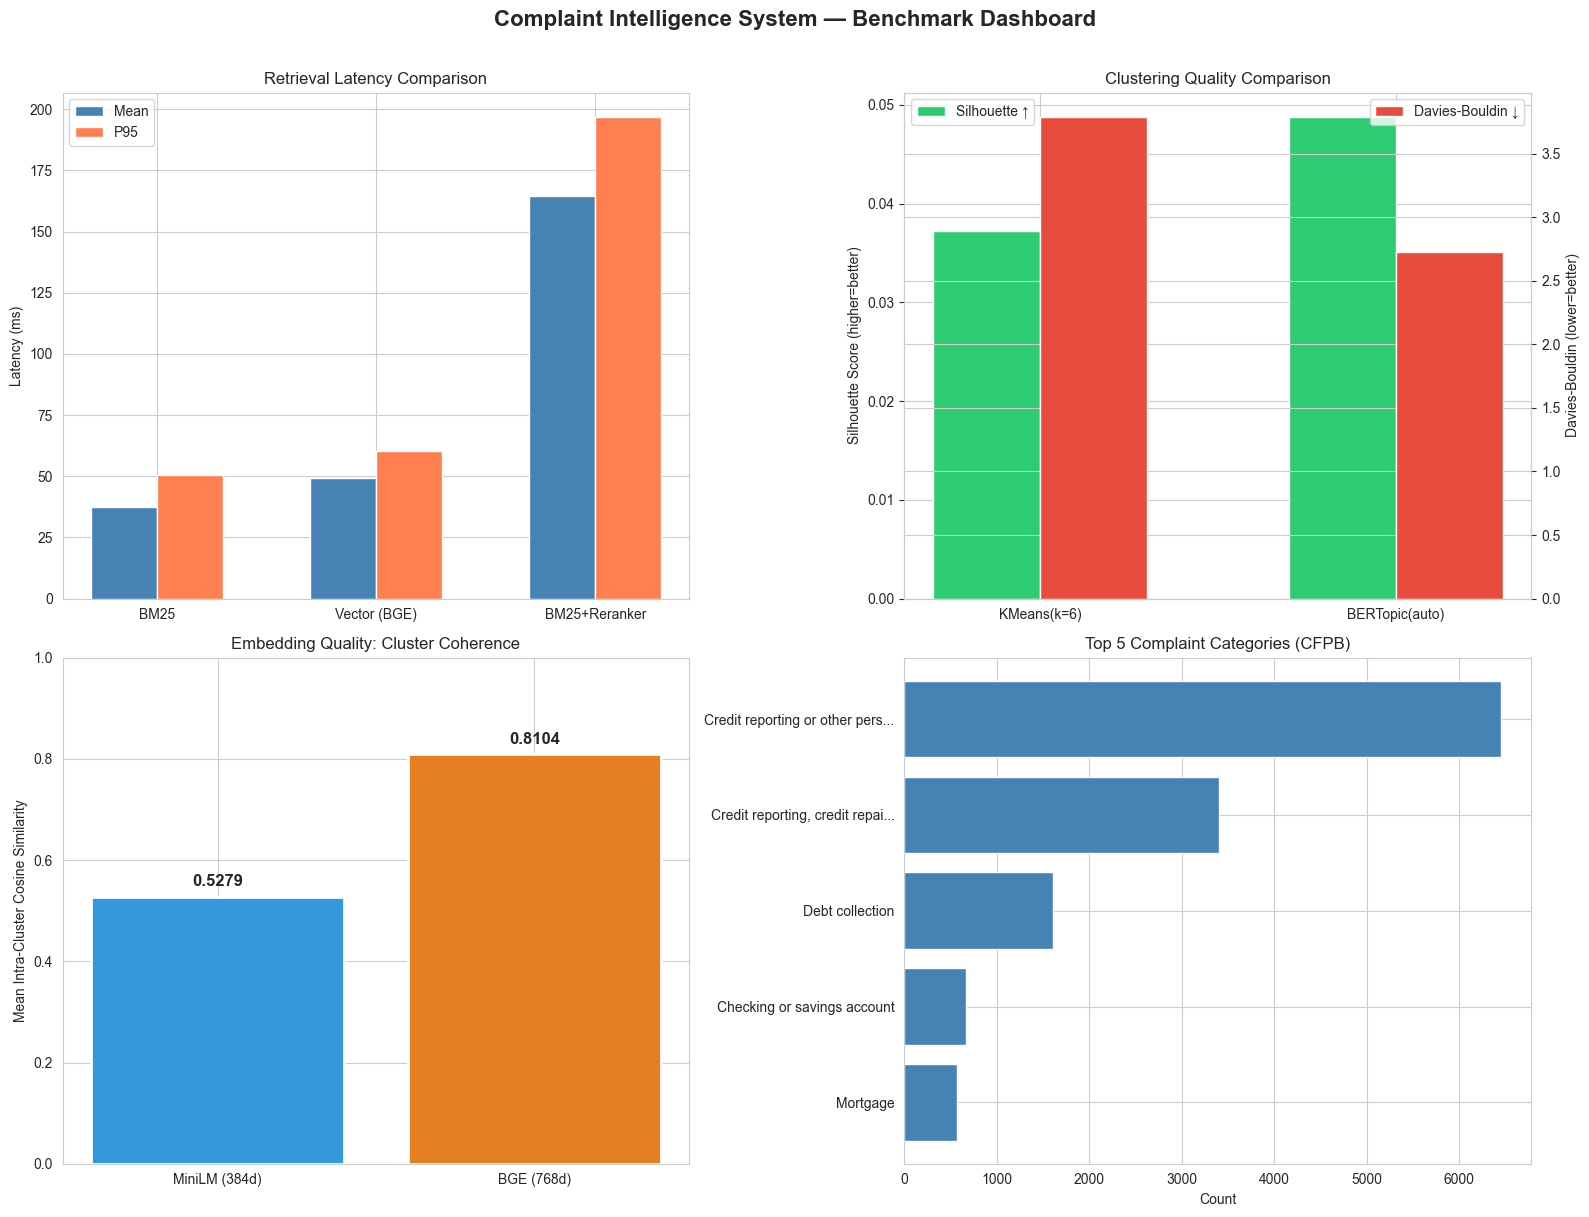

In [18]:
"""Cell 16: Final comparison dashboard"""
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Retrieval Latency Comparison
retrievers = list(all_results.keys())
means = [all_results[r]['mean_ms'] for r in retrievers]
p95s = [all_results[r]['p95_ms'] for r in retrievers]

x = np.arange(len(retrievers))
axes[0, 0].bar(x - 0.15, means, 0.3, label='Mean', color='steelblue')
axes[0, 0].bar(x + 0.15, p95s, 0.3, label='P95', color='coral')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(retrievers, fontsize=10)
axes[0, 0].set_ylabel('Latency (ms)')
axes[0, 0].set_title('Retrieval Latency Comparison')
axes[0, 0].legend()

# 2. Clustering Quality: KMeans vs BERTopic
methods = ['KMeans(k=6)', 'BERTopic(auto)']
sil_scores = [comparison['kmeans']['silhouette'], comparison['bertopic']['silhouette']]
db_scores = [comparison['kmeans']['davies_bouldin'], comparison['bertopic']['davies_bouldin']]

ax2 = axes[0, 1]
x2 = np.arange(2)
bars1 = ax2.bar(x2 - 0.15, sil_scores, 0.3, label='Silhouette ↑', color='#2ecc71')
bars2_ax = ax2.twinx()
bars2 = bars2_ax.bar(x2 + 0.15, db_scores, 0.3, label='Davies-Bouldin ↓', color='#e74c3c')
ax2.set_xticks(x2)
ax2.set_xticklabels(methods)
ax2.set_ylabel('Silhouette Score (higher=better)')
bars2_ax.set_ylabel('Davies-Bouldin (lower=better)')
ax2.set_title('Clustering Quality Comparison')
ax2.legend(loc='upper left')
bars2_ax.legend(loc='upper right')

# 3. Embedding Coherence: MiniLM vs BGE
models = ['MiniLM (384d)', 'BGE (768d)']
coherences = [0.5279, 0.8104]
colors = ['#3498db', '#e67e22']
axes[1, 0].bar(models, coherences, color=colors, edgecolor='white', linewidth=2)
axes[1, 0].set_ylabel('Mean Intra-Cluster Cosine Similarity')
axes[1, 0].set_title('Embedding Quality: Cluster Coherence')
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(coherences):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# 4. Product Distribution (top 5)
top5 = df['product'].value_counts().head(5)
short_names = [p[:30] + '...' if len(p) > 30 else p for p in top5.index]
axes[1, 1].barh(short_names, top5.values, color='steelblue')
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Top 5 Complaint Categories (CFPB)')

plt.suptitle('Complaint Intelligence System — Benchmark Dashboard', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [19]:
"""Cell 17: Save all verified benchmark results"""
import json

benchmark_summary = {
    "dataset": {
        "source": "CFPB Consumer Complaints",
        "total_rows": len(df),
        "unique_texts": df['complaint_text'].nunique(),
        "products": df['product'].nunique(),
        "issues": df['issue'].nunique(),
        "date_range": f"{df['date_parsed'].min().strftime('%Y-%m-%d')} to {df['date_parsed'].max().strftime('%Y-%m-%d')}",
    },
    "embeddings": {
        "minilm": {"dim": 384, "model": "all-MiniLM-L6-v2", "coherence": 0.5279},
        "bge": {"dim": 768, "model": "BAAI/bge-base-en-v1.5", "coherence": 0.8104},
    },
    "clustering": comparison,
    "retrieval": all_results,
    "verified_on": pd.Timestamp.now().isoformat(),
}

output_path = os.path.join(PROJECT_ROOT, 'data', 'processed', 'benchmark_results.json')
with open(output_path, 'w') as f:
    json.dump(benchmark_summary, f, indent=2)

print(f"✅ Benchmark results saved to {output_path}")
print(f"\n--- Summary ---")
print(json.dumps(benchmark_summary, indent=2))


✅ Benchmark results saved to c:\Users\aswan\My ML projects\complaint-intelligence-system\data\processed\benchmark_results.json

--- Summary ---
{
  "dataset": {
    "source": "CFPB Consumer Complaints",
    "total_rows": 15000,
    "unique_texts": 12923,
    "products": 20,
    "issues": 140,
    "date_range": "2015-03-20 to 2025-11-20"
  },
  "embeddings": {
    "minilm": {
      "dim": 384,
      "model": "all-MiniLM-L6-v2",
      "coherence": 0.5279
    },
    "bge": {
      "dim": 768,
      "model": "BAAI/bge-base-en-v1.5",
      "coherence": 0.8104
    }
  },
  "clustering": {
    "kmeans": {
      "method": "KMeans",
      "n_clusters": 6,
      "n_outliers": 0,
      "silhouette": 0.0372,
      "calinski_harabasz": 533.23,
      "davies_bouldin": 3.7914
    },
    "bertopic": {
      "method": "BERTopic",
      "n_clusters": 51,
      "n_outliers": 4676,
      "silhouette": 0.0488,
      "calinski_harabasz": 100.34,
      "davies_bouldin": 2.7266
    }
  },
  "retrieval": {
   